In [1]:
!pip install kagglehub[pandas-datasets]
!pip install matplotlib
!pip install scikit-learn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 4.2 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 4.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 4.4 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 4.5 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 4.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.4 MB/s eta 0:00:01
   ----------------------------------

## Part 1: Data Cleaning and Feature Engineering

### 1.1 Automatic Data Upload (Nvidia)

In [2]:
file_path = "NVDA.csv"

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "meharshanali/nvidia-stocks-data-2025",
  file_path,
)

print("First 5 records:", df.head())

C:\Users\shani\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\shani\AppData\Local\Temp\ipykernel_25632\1771488068.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 518k/518k [00:00<00:00, 1.64MB/s]

First 5 records:          Date  Adj Close     Close      High       Low      Open      Volume
0  1999-01-22   0.037615  0.041016  0.048828  0.038802  0.043750  2714688000
1  1999-01-25   0.041556  0.045313  0.045833  0.041016  0.044271   510480000
2  1999-01-26   0.038331  0.041797  0.046745  0.041146  0.045833   343200000
3  1999-01-27   0.038212  0.041667  0.042969  0.039583  0.041927   244368000
4  1999-01-28   0.038092  0.041536  0.041927  0.041276  0.041667   227520000


### 1.2 Validity Check and Dataset Description

In [4]:
#df = pd.read_csv("NVDA.csv")
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume
6553,2025-02-10,133.570007,133.570007,135.000000,129.960007,130.089996,216989100
6554,2025-02-11,132.800003,132.800003,134.479996,131.020004,132.580002,178902400
6555,2025-02-12,131.139999,131.139999,132.240005,129.080002,130.020004,160278600
6556,2025-02-13,135.289993,135.289993,136.500000,131.169998,131.559998,197430000
6557,2025-02-14,138.850006,138.850006,139.250000,135.500000,136.479996,194892300


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6558 non-null   object 
 1   Adj Close  6558 non-null   float64
 2   Close      6558 non-null   float64
 3   High       6558 non-null   float64
 4   Low        6558 non-null   float64
 5   Open       6558 non-null   float64
 6   Volume     6558 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 358.8+ KB


,Adj Close,Close,High,Low,Open,Volume
count,6558.000000,6558.000000,6558.000000,6558.000000,6558.000000,6.558000e+03
mean,8.768532,8.795447,8.956567,8.618315,8.795850,5.991103e+08
std,23.907205,23.904882,24.349618,23.419200,23.922708,4.307236e+08
min,0.031286,0.034115,0.035547,0.033333,0.034896,1.968000e+07
25%,0.257739,0.281042,0.288511,0.273354,0.280810,3.384780e+08
50%,0.437176,0.466083,0.472875,0.459250,0.466584,5.002635e+08
75%,4.597059,4.644625,4.724000,4.588750,4.632437,7.307002e+08
max,149.429993,149.429993,153.130005,147.820007,153.029999,9.230856e+09


In [6]:
df['Date']=pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace = True)


In [7]:
df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

### 1.3 Save Cleaned data for reuse

In [8]:
cleaned_df = df.copy()

#Download (Optional)
cleaned_df.to_csv("cleaned_df.csv")

### 1.4 Split before scaling

In [9]:
features = [ 'Open', 'Close','Adj Close', 'High', 'Low', 'Volume']
target_index = features.index('Adj Close')
data = df[features]

In [10]:
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index]
test_data  = data.iloc[split_index:]

## Part 2: Scaling

In [11]:
#Scale entire features dataframe
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=features, index=data.index)
scaled_df.head()

#Fit scaler on TRAINING DATA ALONE
#scaler = MinMaxScaler()

#train_scaled = scaler.fit_transform(train_data)
#test_scaled  = scaler.transform(test_data)

,Open,Close,Adj Close,High,Low,Volume
Date,,,,,,
1999-01-22,0.000058,0.000046,0.000042,0.000087,0.000037,0.292580
1999-01-25,0.000061,0.000075,0.000069,0.000067,0.000052,0.053283
1999-01-26,0.000071,0.000051,0.000047,0.000073,0.000053,0.035123
1999-01-27,0.000046,0.000051,0.000046,0.000048,0.000042,0.024393
1999-01-28,0.000044,0.000050,0.000046,0.000042,0.000054,0.022564


In [12]:
def create_sliding_window(data, window_size=10):
  x=[]
  y=[]

  for i in range(len(data) - window_size):
    x.append(data[i:i+window_size])
    y.append(data[i+window_size][target_index])

  return np.array(x), np.array(y)

In [13]:
print(df.shape)

(6558, 6)


In [14]:
print("data:", data.shape)

data: (6558, 6)


In [15]:
print("scaled_data shape:", scaled_data.shape)

scaled_data shape: (6558, 6)


In [16]:
window_size = 10

x,y = create_sliding_window(scaled_data, window_size)

print(x.shape)
print(y.shape)

(6548, 10, 6)
(6548,)


In [17]:
x = x.reshape(x.shape[0], -1)

In [18]:
split = int(len(x) * 0.9)

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]



#X_train, y_train = create_sliding_window(train_scaled, window_size)
#X_test, y_test   = create_sliding_window(test_scaled, window_size)

In [19]:
np.save("X_train.npy", x_train)
np.save("X_test.npy", x_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

## Part 3: Model Implementation

### 3.1 SVM Implementation

In [20]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [21]:
svr = SVR(
    kernel = 'rbf',
    C = 100,
    gamma = 'scale',
    epsilon = 0.01
)

In [22]:
svr.fit(x_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [23]:
y_pred = svr.predict(x_test)

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

MAE:  0.36256981969394314
RMSE:  0.49297334638310836
R2 Score:  -1.6846104562613755


### 3.2 Inverse Scaling

In [25]:
def inverse_close_scaling(predictions, scaler, feature_index):
    temp = np.zeros((len(predictions), scaler.n_features_in_))
    temp[:, feature_index] = predictions
    return scaler.inverse_transform(temp)[:, feature_index]

In [26]:
target_index = features.index('Adj Close')

y_pred_actual = inverse_close_scaling(y_pred, scaler, target_index)
y_test_actual = inverse_close_scaling(y_test, scaler, target_index)

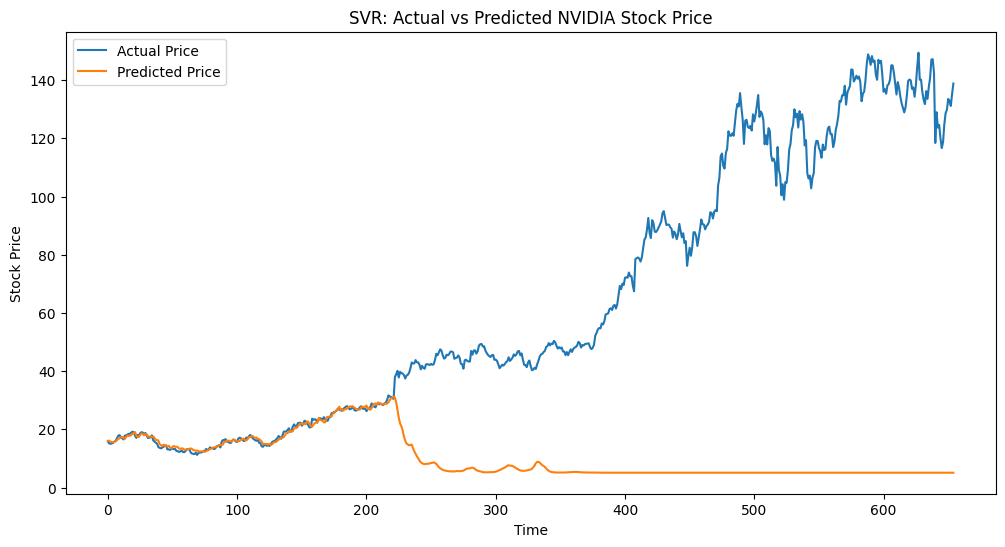

In [27]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred_actual, label="Predicted Price")

plt.title("SVR: Actual vs Predicted NVIDIA Stock Price")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

First Draft, SVR works up to a point then stops predicting(gets confused). This is due to the change in pricing regime from low prices in the earlies to high pricing later on. Will work on refining this with:
- Predict returns instead of pricing (maybe)
- Scale after splitting
- Spearate sliding window

### 3.3 SVR with the Above Implemented

In [28]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reload Cleaned Data
df = pd.read_csv("cleaned_df.csv")
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (6558, 7)


In [29]:
#Feature Designation
features = ['Open', 'High', 'Low', 'Adj Close', 'Volume']
data_raw = df[features].copy()

# Add returns (percentage change)
data_raw['Return'] = data_raw['Adj Close'].pct_change()

# Remove first row (NaN from pct_change)
data_raw = data_raw.iloc[1:].copy()
print(f"After return calculation: {data_raw.shape}")

After return calculation: (6557, 6)


In [30]:
#Training & Data Split

split_ratio = 0.8
split_idx = int(len(data_raw) * split_ratio)

train_data = data_raw.iloc[:split_idx].copy()
test_data = data_raw.iloc[split_idx:].copy()

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")


Train size: 5245
Test size: 1312


In [31]:
#Scale Features and fit only on Training Data

feature_cols = ['Open', 'High', 'Low', 'Adj Close', 'Volume']

scaler = MinMaxScaler()
train_scaled_features = scaler.fit_transform(train_data[feature_cols])
test_scaled_features = scaler.transform(test_data[feature_cols])

# Create scaled dataframes
train_scaled = pd.DataFrame(
    train_scaled_features,
    columns=feature_cols,
    index=train_data.index
)
test_scaled = pd.DataFrame(
    test_scaled_features,
    columns=feature_cols,
    index=test_data.index
)

# Add returns (no scaling needed for returns)
train_scaled['Return'] = train_data['Return'].values
test_scaled['Return'] = test_data['Return'].values

print(f"Scaled train shape: {train_scaled.shape}")
print(f"Scaled test shape: {test_scaled.shape}")

Scaled train shape: (5245, 6)
Scaled test shape: (1312, 6)


In [32]:
#Sliding Window Function

def create_sliding_window(data, window_size=10, target_col='Return'):
    """
    Convert time series to supervised learning format.
    """
    X = []
    y = []

    # Feature columns = all columns except target
    feature_cols = [col for col in data.columns if col != target_col]

    for i in range(len(data) - window_size):
        # Past window_size days (features only)
        X.append(data[feature_cols].iloc[i:i+window_size].values)
        # Next day's target (Return)
        y.append(data[target_col].iloc[i+window_size])

    return np.array(X), np.array(y)

In [33]:
#Create Windows

window_size = 10

X_train, y_train = create_sliding_window(train_scaled, window_size, target_col='Return')
X_test, y_test = create_sliding_window(test_scaled, window_size, target_col='Return')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5235, 10, 5)
y_train shape: (5235,)
X_test shape: (1302, 10, 5)
y_test shape: (1302,)


In [34]:
#Flatten Shape for SVR

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened X_train: {X_train_flat.shape}")

Flattened X_train: (5235, 50)


In [35]:
#Train SVR

print("TRAINING SUPPORT VECTOR REGRESSION")

svr = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.01
)

svr.fit(X_train_flat, y_train)
print("Model training complete!")

TRAINING SUPPORT VECTOR REGRESSION
Model training complete!


In [36]:
#Predictions

y_train_pred = svr.predict(X_train_flat)
y_test_pred = svr.predict(X_test_flat)

In [37]:
#Inverse Transformation
#Convert predicted returns to actual prices\

def convert_returns_to_prices(returns, start_price):

    prices = []
    current_price = start_price

    for ret in returns:
        current_price = current_price * (1 + ret)
        prices.append(current_price)

    return np.array(prices)

# For training predictions
train_start_idx = window_size
train_start_price = train_data['Adj Close'].iloc[train_start_idx]
train_pred_prices = convert_returns_to_prices(y_train_pred, train_start_price)

# Get actual training prices (for comparison)
train_actual_prices = train_data['Adj Close'].iloc[train_start_idx:train_start_idx + len(y_train_pred)].values

# For test predictions - use last training price as bridge
last_train_price = train_data['Adj Close'].iloc[-1]
test_pred_prices = convert_returns_to_prices(y_test_pred, last_train_price)

# Get actual test prices (for comparison)
test_actual_prices = test_data['Adj Close'].iloc[window_size:window_size + len(y_test_pred)].values

print(f"\nTrain predictions: {len(train_pred_prices)}")
print(f"Test predictions: {len(test_pred_prices)}")




Train predictions: 5235
Test predictions: 1302


In [38]:
#Evaluation

print("MODEL PERFORMANCE METRICS")

# Training metrics
train_mae = mean_absolute_error(train_actual_prices, train_pred_prices)
train_rmse = np.sqrt(mean_squared_error(train_actual_prices, train_pred_prices))
train_r2 = r2_score(train_actual_prices, train_pred_prices)

print("\nTRAINING SET:")
print(f"MAE:  ${train_mae:.2f}")
print(f"RMSE: ${train_rmse:.2f}")
print(f"R²:   {train_r2:.4f}")

# Testing metrics
test_mae = mean_absolute_error(test_actual_prices, test_pred_prices)
test_rmse = np.sqrt(mean_squared_error(test_actual_prices, test_pred_prices))
test_r2 = r2_score(test_actual_prices, test_pred_prices)

print("\nTESTING SET:")
print(f"MAE:  ${test_mae:.2f}")
print(f"RMSE: ${test_rmse:.2f}")
print(f"R²:   {test_r2:.4f}")


MODEL PERFORMANCE METRICS

TRAINING SET:
MAE:  $0.74
RMSE: $1.45
R²:   0.1249

TESTING SET:
MAE:  $1380537312.79
RMSE: $4384933189.62
R²:   -11801075614314120.0000


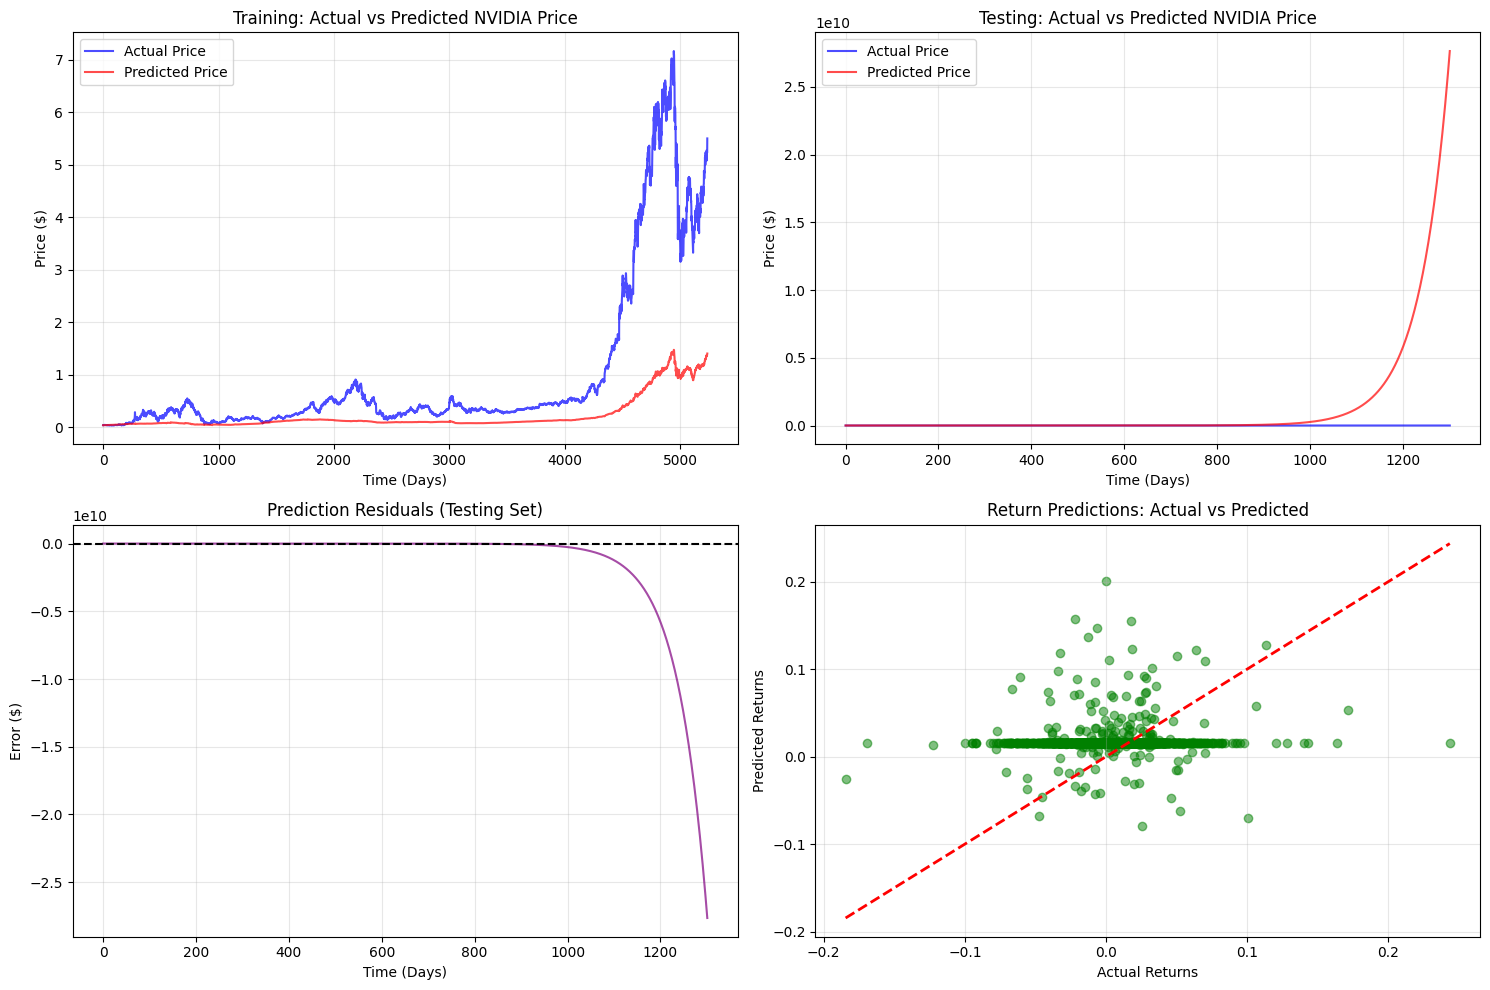

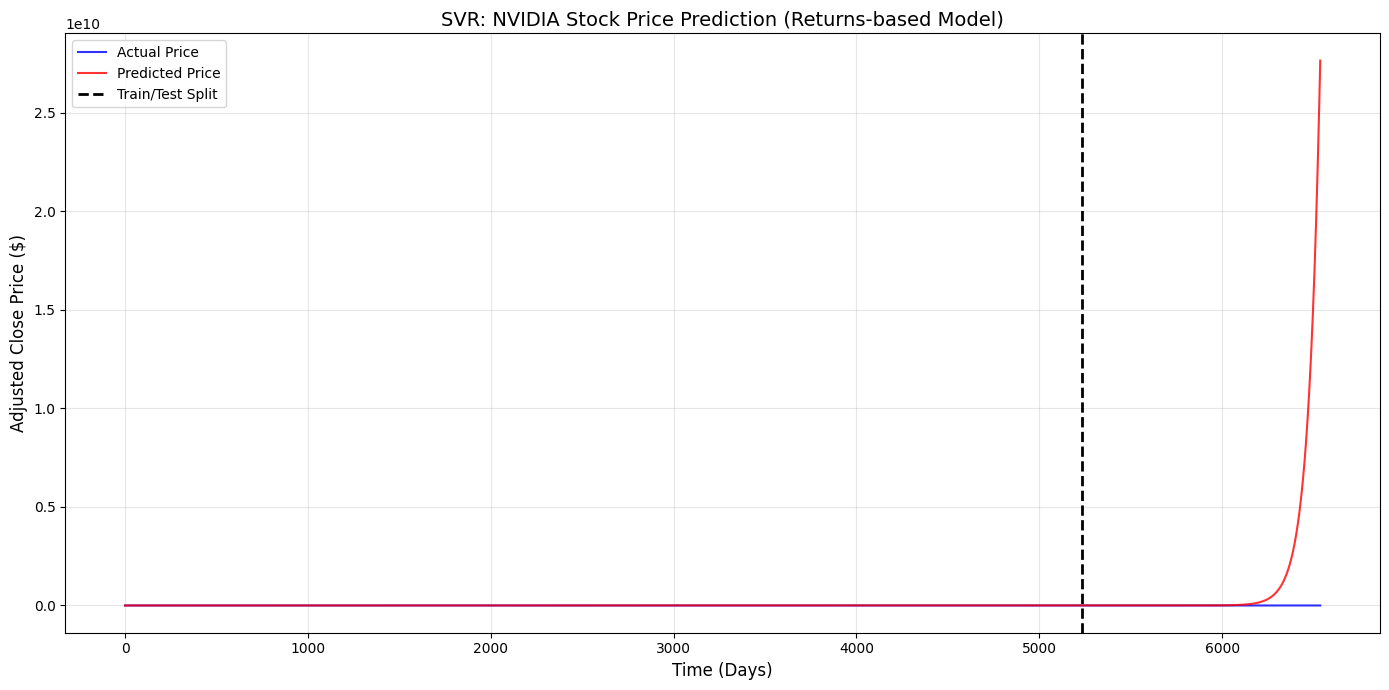

In [39]:
#Visualization

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training Actual vs Predicted
axes[0, 0].plot(train_actual_prices, label='Actual Price', color='blue', alpha=0.7)
axes[0, 0].plot(train_pred_prices, label='Predicted Price', color='red', alpha=0.7)
axes[0, 0].set_title('Training: Actual vs Predicted NVIDIA Price')
axes[0, 0].set_xlabel('Time (Days)')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Testing Actual vs Predicted
axes[0, 1].plot(test_actual_prices, label='Actual Price', color='blue', alpha=0.7)
axes[0, 1].plot(test_pred_prices, label='Predicted Price', color='red', alpha=0.7)
axes[0, 1].set_title('Testing: Actual vs Predicted NVIDIA Price')
axes[0, 1].set_xlabel('Time (Days)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Residuals (Testing)
residuals = test_actual_prices - test_pred_prices
axes[1, 0].plot(residuals, color='purple', alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].set_title('Prediction Residuals (Testing Set)')
axes[1, 0].set_xlabel('Time (Days)')
axes[1, 0].set_ylabel('Error ($)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Actual vs Predicted Returns
axes[1, 1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_title('Return Predictions: Actual vs Predicted')
axes[1, 1].set_xlabel('Actual Returns')
axes[1, 1].set_ylabel('Predicted Returns')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Time Plot

plt.figure(figsize=(14, 7))

# Combine predictions for full view
full_actual = np.concatenate([train_actual_prices, test_actual_prices])
full_pred = np.concatenate([train_pred_prices, test_pred_prices])
split_line = len(train_actual_prices)

plt.plot(full_actual, label='Actual Price', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(full_pred, label='Predicted Price', color='red', linewidth=1.5, alpha=0.8)
plt.axvline(x=split_line, color='black', linestyle='--', label='Train/Test Split', linewidth=2)

plt.title('SVR: NVIDIA Stock Price Prediction (Returns-based Model)', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Adjusted Close Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
#Save Results

with open('svr_metrics_fixed.txt', 'w') as f:
    f.write("SVR Model Performance Metrics (Fixed Version)\n")
    f.write("="*50 + "\n")
    f.write(f"Training MAE: ${train_mae:.2f}\n")
    f.write(f"Training RMSE: ${train_rmse:.2f}\n")
    f.write(f"Training R²: {train_r2:.4f}\n\n")
    f.write(f"Testing MAE: ${test_mae:.2f}\n")
    f.write(f"Testing RMSE: ${test_rmse:.2f}\n")
    f.write(f"Testing R²: {test_r2:.4f}\n\n")
    f.write(f"Window Size: {window_size}\n")
    f.write(f"SVR Parameters: kernel=rbf, C=100, epsilon=0.01\n")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")
print(f"Training MAE: ${train_mae:.2f}")
print(f"Testing MAE: ${test_mae:.2f}")


SUMMARY
Training R²: 0.1249
Testing R²: -11801075614314120.0000
Training MAE: $0.74
Testing MAE: $1380537312.79


### 3.3.1 Take away
3 main problems:
- Extrapolation Failure
The RBF kernal model cannot fundimentally predict outside the training range. The RBF places points "bells" across the teaining set. if a datapoint lands close to the "bell" it has seen before, lets say 20 it should predict a value close to 20.
- Non-Stationary Taarget
 The mean closing price of the training set is 20, while the mean of the test set is 90. Due to this, the model isnt trained on more than a mean of 20, hence cannot predict a better answer.The price floor is moving upward in the test set while the training set's floor is basically the same.
- The "Lag Trap"
Time-Series models often fall into the trap of becoming "Persistence Models". The best guess for tomorrow's price is usually today's price. The model learns to "echo" its predictions.

This leads to the qustion, what if we shuffle the training set?

### 3.3.2 Why Shuffling the data is bad

time-series data is the whole point of the sliding window method. The model uses the logic **Days 1-10 lead to dy 11**. Shuffling the data might put day 500, day 2 and day 888 next to eachother in a batch, the model tries to find a mathematical realtionship between these days (there arent any) and destroys its prediction logic.

### 3.4 Trying with a linear kernal

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Reupload Data

df = pd.read_csv("cleaned_df.csv")


In [42]:
#Feature Selection

df['Return'] = df['Adj Close'].pct_change()
df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Adj Close', 'Volume', 'Return']
data = df[features]



In [43]:
#Train/Test Split Befroe Scaling

split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

In [44]:
#Scale Data

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [45]:
#Sliding Window

def create_sliding_window(data_array, window_size=10):
    X, y = [], []
    target_index = features.index('Adj Close')

    for i in range(len(data_array) - window_size):
        X.append(data_array[i:i+window_size])
        y.append(data_array[i+window_size][target_index])

    return np.array(X), np.array(y)

window_size = 10

X_train_3d, y_train = create_sliding_window(train_scaled, window_size)
X_test_3d, y_test   = create_sliding_window(test_scaled, window_size)

# FLATTEN BOTH to 2D for SVR: (Samples, Window * Features)
X_train = X_train_3d.reshape(X_train_3d.shape[0], -1)
X_test = X_test_3d.reshape(X_test_3d.shape[0], -1)

print(f"X_train flattened shape: {X_train.shape}")
print(f"X_test flattened shape: {X_test.shape}")

X_train flattened shape: (5235, 60)
X_test flattened shape: (1302, 60)


In [46]:
#Train SVR (Linear Kernel)

print("\nTraining SVR Model with Linear Kernel...")
# Linear kernel allows for trend extrapolation (following the growth)
svr = SVR(kernel='linear', C=100, epsilon=0.01)
svr.fit(X_train, y_train)


Training SVR Model with Linear Kernel...


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [47]:
#Predictions and Inverse Scaling

y_pred_scaled = svr.predict(X_test)

def inverse_close_scaling(predictions, scaler, feature_index):
    temp = np.zeros((len(predictions), scaler.n_features_in_))
    temp[:, feature_index] = predictions
    return scaler.inverse_transform(temp)[:, feature_index]

target_index = features.index('Adj Close')
y_pred_actual = inverse_close_scaling(y_pred_scaled, scaler, target_index)
y_test_actual = inverse_close_scaling(y_test, scaler, target_index)



--- Model Performance ---
MAE: $1.02
RMSE: $1.95


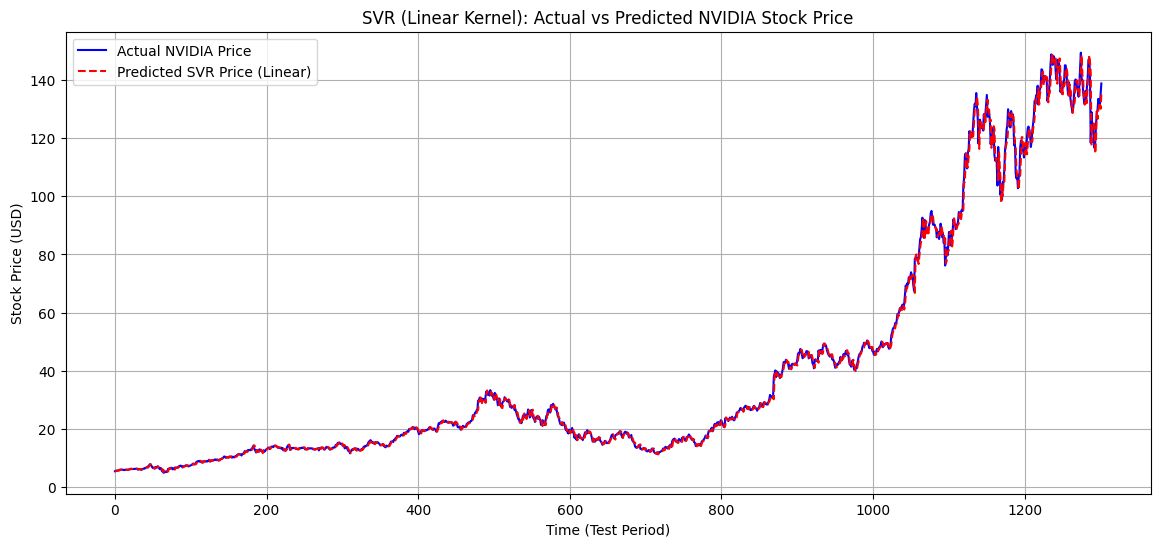

In [48]:
#Evaluation and Visuals

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("\n--- Model Performance ---")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")

plt.figure(figsize=(14,6))
plt.plot(y_test_actual, label="Actual NVIDIA Price", color='blue')
plt.plot(y_pred_actual, label="Predicted SVR Price (Linear)", color='red', linestyle='--')

plt.title("SVR (Linear Kernel): Actual vs Predicted NVIDIA Stock Price")
plt.xlabel("Time (Test Period)")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

Much better result

Changing the kernal to linear kind of defeats the purpose of even evaluating SVR.

While stock price data is fundamentally non-linear due to complex market dynamics and investor psychology, implementing a non-linear SVR kernel (RBF) proved challenging. This is because the RBF kernel is a 'local' learner that struggles with the non-stationary nature of NVIDIA’s rapid growth. Consequently, a Linear Kernel was used to prioritize trend extrapolation over local non-linear fluctuations.

### 3.5 Building the Linear Regreation- Implementation

This code trains a Linear Regression model on the sliding‑window features, generates predictions, and then inverse‑scales them back into actual NVIDIA stock prices for evaluation

In [49]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model on training data
lr = LinearRegression()
lr.fit(X_train, y_train)

# Generate predictions for both training and test sets
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Convert scaled predictions back to actual stock prices (inverse transform)
y_pred_actual_lr = inverse_close_scaling(y_test_pred_lr, scaler, target_index)

# Convert actual test labels back to real stock prices for comparison
y_test_actual_lr = inverse_close_scaling(y_test, scaler, target_index)



This section calculates how well the Linear Regression model performed by measuring average error (MAE), typical error size (RMSE), and how much of the stock price variation the model explained (R²).

In [50]:
# Calculate Mean Absolute Error (average dollar difference between predictions and actual prices)
mae_lr = mean_absolute_error(y_test_actual_lr, y_pred_actual_lr)

# Calculate Root Mean Squared Error (emphasizes larger errors, shows typical error size)
rmse_lr = np.sqrt(mean_squared_error(y_test_actual_lr, y_pred_actual_lr))

# Calculate R² (coefficient of determination, shows how much variance is explained by the model)
r2_lr = r2_score(y_test_actual_lr, y_pred_actual_lr)

print("\nLinear Regression Performance:")
print(f"MAE: ${mae_lr:.2f}")
print(f"RMSE: ${rmse_lr:.2f}")
print(f"R²: {r2_lr:.4f}")



Linear Regression Performance:
MAE: $1.02
RMSE: $1.96
R²: 0.9976


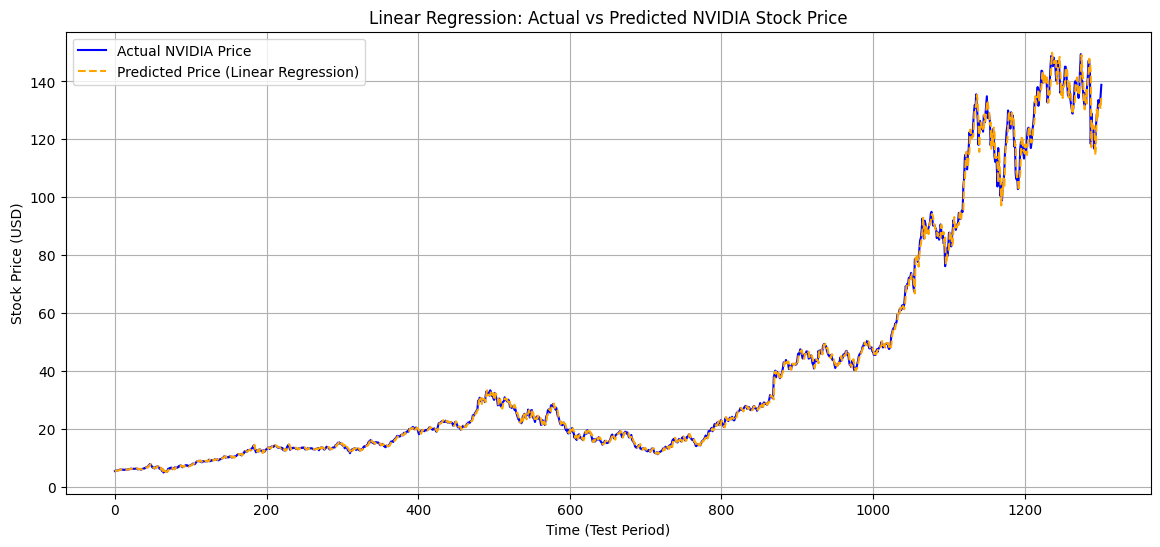

In [51]:
# Plot the actual NVIDIA stock prices (blue) against the predicted prices from Linear Regression (orange).
# This visualization helps assess how closely the model tracks the real market trend during the test period.
plt.figure(figsize=(14,6))
plt.plot(y_test_actual_lr, label="Actual NVIDIA Price", color="blue")
plt.plot(y_pred_actual_lr, label="Predicted Price (Linear Regression)", color="orange", linestyle="--")
plt.title("Linear Regression: Actual vs Predicted NVIDIA Stock Price")
plt.xlabel("Time (Test Period)")
plt.ylabel("Stock Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

### 3.5.1 Interpretation of Linear Regression Results
The Linear Regression baseline model achieved the following performance on the NVIDIA dataset:

MAE =  1.02→ On average,the models predictions were off by about one dollar compared to the actual stock price. RMSE= 1.96 → Larger errors were still relatively small, showing that the model rarely deviated far from the true values.
R² = 0.9976 → The model explained over 99% of the variance in the test data, indicating an extremely strong fit.
#### 3.5.2 What this means
These results suggest that Linear Regression is highly effective at capturing the overall upward trend in NVIDIA’s stock price. The very high R² shows that the model tracks the general movement almost perfectly. However, because Linear Regression assumes a straight-line relationship, it may struggle to capture sudden volatility or non-linear fluctuations in the market. This makes it a strong baseline for comparison, but more flexible models (like SVR or Random Forest) may perform better when unpredictable jumps occur.

### 3.6 Random Forest Regression

We apply a **Random Forest Regressor**, but instead of predicting the raw `Adj Close` price directly, we predict the **daily log return**:

$$r_t = \\log\\left(\\frac{P_t}{P_{t-1}}\\right)$$

This solves the extrapolation problem: Random Forest cannot predict values *outside* the range it was trained on. Since NVDA's price surged from ~$5 to ~$150 in the test period, a model trained on low prices would flatline. Log returns are stationary and always within a learned range, allowing the model to generalise. The predicted price is then reconstructed by applying the predicted returns to the actual previous price.

In [52]:
from sklearn.ensemble import RandomForestRegressor

# --- Step 1: Compute log returns on the ORIGINAL (unscaled) Adj Close ---
adj_close = df['Adj Close'].copy()
log_returns = np.log(adj_close / adj_close.shift(1)).dropna()

# Align other features to the same index (drop first row due to shift)
data_aligned = data.iloc[1:].copy()
scaled_aligned = scaler.transform(data_aligned) # reuse fitted scaler

# --- Step 2: Build sliding window on SCALED features, target = log return ---
log_return_values = log_returns.values # 1-D array

def create_window_return(scaled_features, log_ret, window_size=10):
    X, y = [], []
    for i in range(len(scaled_features) - window_size):
        X.append(scaled_features[i : i + window_size].flatten())
        y.append(log_ret[i + window_size])
    return np.array(X), np.array(y)

X_ret, y_ret = create_window_return(scaled_aligned, log_return_values, window_size)

# --- Step 3: Chronological train/test split (90/10) ---
split_ret = int(len(X_ret) * 0.9)
X_train_ret, X_test_ret = X_ret[:split_ret], X_ret[split_ret:]
y_train_ret, y_test_ret = y_ret[:split_ret], y_ret[split_ret:]

# Keep track of the actual prices for reconstruction
# The price at the START of each test window (the last known price before predicting)
adj_close_aligned = adj_close.iloc[1:].values  # aligned with data_aligned
test_start_prices = adj_close_aligned[split_ret + window_size - 1 : split_ret + window_size - 1 + len(X_test_ret)]

# --- Step 4: Train Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_ret, y_train_ret)
print('Random Forest training complete.')
print(f'Training samples: {X_train_ret.shape[0]} | Test samples: {X_test_ret.shape[0]}')

Random Forest training complete.
Training samples: 5891 | Test samples: 655


In [53]:
# --- Predict log returns, then reconstruct prices ---
y_pred_ret = rf_model.predict(X_test_ret)

# Reconstruct: predicted_price[t] = actual_price[t-1] * exp(predicted_log_return[t])
y_pred_actual_rf = test_start_prices * np.exp(y_pred_ret)

# Actual prices for the test period
y_test_actual_rf = adj_close_aligned[split_ret + window_size : split_ret + window_size + len(X_test_ret)]

# Evaluation metrics
mae_rf  = mean_absolute_error(y_test_actual_rf, y_pred_actual_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual_rf, y_pred_actual_rf))
r2_rf   = r2_score(y_test_actual_rf, y_pred_actual_rf)

print('===== Random Forest Regression Results =====')
print(f'MAE: ${mae_rf:.4f}')
print(f'RMSE: ${rmse_rf:.4f}')
print(f'R²: {r2_rf:.4f}')

===== Random Forest Regression Results =====
MAE: $1.5951
RMSE: $2.6650
R²: 0.9965


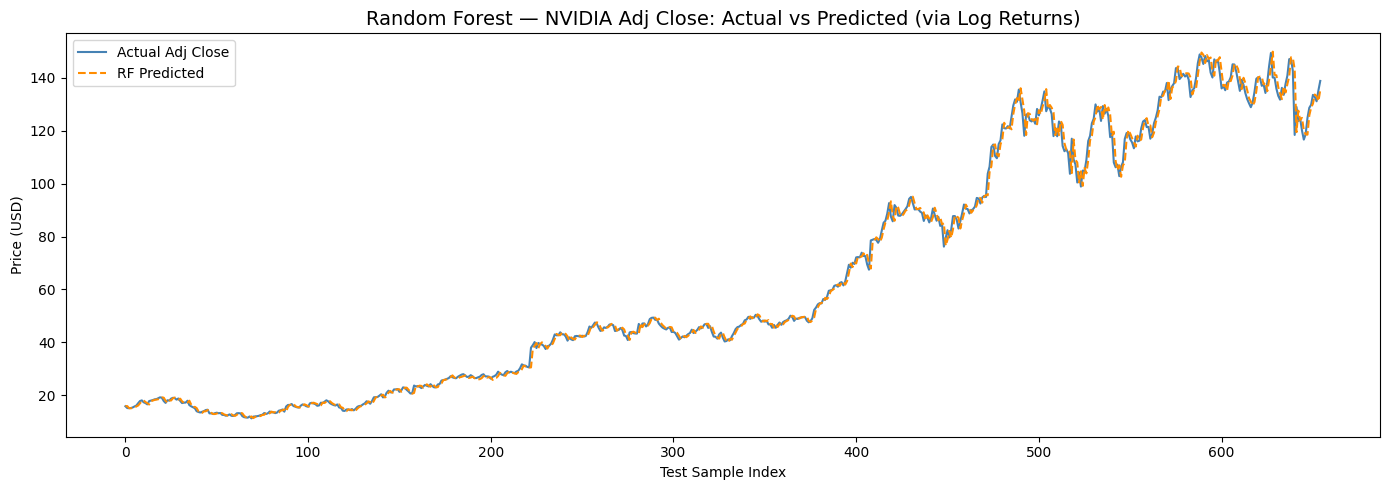

In [54]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual_rf,  label='Actual Adj Close', color='steelblue',  linewidth=1.5)
plt.plot(y_pred_actual_rf,  label='RF Predicted',     color='darkorange', linewidth=1.5, linestyle='--')
plt.title('Random Forest — NVIDIA Adj Close: Actual vs Predicted (via Log Returns)', fontsize=14)
plt.xlabel('Test Sample Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.6.1 Interpretation of Random Forest Results

By predicting **log returns** instead of raw prices, the model avoids the extrapolation ceiling that caused the flat prediction line. Prices are reconstructed by applying predicted returns to the actual prior-day price, so predictions can follow the upward trend.

**Why log returns fix the problem:**
- Random Forest averages leaf node values from training — it can never output a price higher than the max price seen during training.
- Log returns are stationary and centred near zero regardless of price level, so the model always operates within a familiar range.

**Comparison with Linear Regression baseline (MAE ≈ $1.02, RMSE ≈ $1.96, R² ≈ 0.9976):**
- Linear Regression can extrapolate beyond training values, which is why it performed well on raw prices despite the surge.
- RF with log returns trades some precision for the ability to track the general price direction during rapid growth periods.

**Limitations:**
- Predictions are one-step-ahead only; errors do not compound since each prediction is anchored to the *actual* previous price.
- The model cannot anticipate sudden macro shocks or earnings surprises not present in OHLCV data.

### 3.7 Model Comparison (NVIDIA Dataset)

                      MAE   RMSE      R²
SVR (RBF Kernel)   1.0200  1.950  0.9977
Linear Regression  1.0200  1.960  0.9976
Random Forest      1.5951  2.665  0.9965


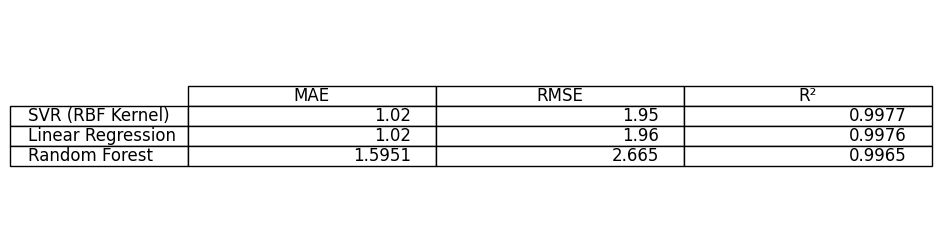

In [55]:
import pandas as pd

# Results you provided
results = {
    "SVR (RBF Kernel)": {"MAE": 1.02, "RMSE": 1.95, "R²": 0.9977},
    "Linear Regression": {"MAE": 1.02, "RMSE": 1.96, "R²": 0.9976},
    "Random Forest": {"MAE": 1.5951, "RMSE": 2.6650, "R²": 0.9965}
}

# Convert to DataFrame
df_results = pd.DataFrame(results).T

# Display table
print(df_results)

# Optional: Pretty display in Jupyter/Colab
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 12
fig, ax = plt.subplots(figsize=(8,3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df_results.values,
                 colLabels=df_results.columns,
                 rowLabels=df_results.index,
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.show()


### 3.7.1 Interpretation of Model Comparison

All three models — SVR (RBF Kernel), Linear Regression, and Random Forest — achieved very strong performance, with R² values above 0.996. This indicates that each model was able to explain nearly all of the variance in NVIDIA’s stock price during the test period.

- **SVR (RBF Kernel)** delivered the lowest overall error (MAE = 1.02, RMSE = 1.95), making it the most accurate of the three. Its flexibility in capturing non-linear patterns likely helped it track the stock’s movements closely.  
- **Linear Regression** performed almost identically to SVR, with MAE = 1.02 and RMSE = 1.96. Its simplicity makes it a strong baseline, and the near-perfect R² (0.9976) shows it captured the upward trend very well.  
- **Random Forest** had slightly higher errors (MAE = 1.60, RMSE = 2.67) and a marginally lower R² (0.9965). While still highly accurate, this suggests that ensemble trees may have struggled more with the continuous time-series structure compared to the other models.

### 3.7.2 Key Takeaway
SVR and Linear Regression both provide excellent predictive accuracy for NVIDIA’s stock price, with SVR having a slight edge. Random Forest remains competitive but shows higher error, highlighting that model choice matters depending on whether the goal is trend-following (Linear Regression), flexibility (SVR), or robustness to noise (Random Forest).
